In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.modeling import (
    run_experiment,
    tune_model,
    compare_models,
    cross_validate_best_config,
    plot_strategy_comparison,
    plot_ratio_impact,
    plot_confusion_matrix_heatmap,
    plot_all_confusion_matrices,
    plot_precision_recall_curve,
    plot_roc_curve,
    ModelingPreparer
)

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


#### LOAD DATA

In [2]:
df_ecomm = pd.read_csv('../data/processed/ecommerce_processed.csv')
df_credit = pd.read_csv('../data/processed/creditcard_cleaned.csv')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"E-commerce: {df_ecomm.shape}, Fraud rate: {df_ecomm['class'].mean()*100:.2f}%")
print(f"Credit Card: {df_credit.shape}, Fraud rate: {df_credit['Class'].mean()*100:.4f}%")

DATA LOADED
E-commerce: (151112, 19), Fraud rate: 9.36%
Credit Card: (283726, 31), Fraud rate: 0.1667%


### E-COMMERCE MODELING AND EXPERIMENTS

In [5]:
print("\n" + "="*60)
print("CURRENT CLASS RATIOS")
print("="*60)

ecomm_ratio = df_ecomm['class'].value_counts()
credit_ratio = df_credit['Class'].value_counts()

print(f"E-commerce: Legit={ecomm_ratio[0]:,}, Fraud={ecomm_ratio[1]:,} → 1:{ecomm_ratio[0]/ecomm_ratio[1]:.1f}")
print(f"Credit Card: Legit={credit_ratio[0]:,}, Fraud={credit_ratio[1]:,} → 1:{credit_ratio[0]/credit_ratio[1]:.1f}")


CURRENT CLASS RATIOS
E-commerce: Legit=136,961, Fraud=14,151 → 1:9.7
Credit Card: Legit=283,253, Fraud=473 → 1:598.8


In [6]:
print("\n" + "="*70)
print("E-COMMERCE EXPERIMENTS")
print("="*70)

ecomm_results = []

# Baseline (Logistic Regression)
print("\nBASELINE (No Resampling)")
print("-" * 55)
result = run_experiment(df_ecomm, 'class', strategy='none', model_type='logistic', threshold=0.30)
ecomm_results.append(result)
print(f"   F1: {result['f1_score']:.4f} | Precision: {result['precision']:.4f} | Recall: {result['recall']:.4f} | AUPRC: {result['auprc']:.4f}")
print(f"   Train: {result['train_shape'][0]:,} | Test: {result['test_shape'][0]:,}")


E-COMMERCE EXPERIMENTS

BASELINE (No Resampling)
-------------------------------------------------------
   F1: 0.4208 | Precision: 0.2939 | Recall: 0.7403 | AUPRC: 0.6668
   Train: 120,889 | Test: 30,223


In [7]:
# SMOTE Experiments
print("\nSMOTE EXPERIMENTS")
print("-" * 75)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8} {'After Ratio':<12}")
print("-" * 65)

for ratio in [0.2, 0.33, 0.5, 0.75, 1.0]:
    result = run_experiment(df_ecomm, 'class', strategy='smote', target_ratio=ratio, model_type='xgboost', threshold=0.30)
    ecomm_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f} {result['after_ratio']:<12}")

# Best SMOTE
best_smote = max([r for r in ecomm_results if r['strategy'] == 'smote'], key=lambda x: x['f1_score'])
print(f"\nBest SMOTE: Ratio={best_smote['target_ratio']}, F1={best_smote['f1_score']:.4f}, Precision={best_smote['precision']:.4f}, Recall={best_smote['recall']:.4f}")

# Undersampling Experiments
print("\nUNDERSAMPLING EXPERIMENTS")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.2, 0.33, 0.5, 0.75, 1.0]:
    result = run_experiment(df_ecomm, 'class', strategy='undersample', target_ratio=ratio, model_type='xgboost', threshold=0.30)
    ecomm_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")


SMOTE EXPERIMENTS
---------------------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC    After Ratio 
-----------------------------------------------------------------
0.20     0.6850   0.8559     0.5710   0.7051   1:5.0       
0.33     0.6648   0.7665     0.5869   0.7047   1:3.0       
0.50     0.6453   0.6824     0.6120   0.7061   1:2.0       
0.75     0.6338   0.6277     0.6399   0.7061   1:1.3       
1.00     0.6262   0.5974     0.6580   0.7064   1:1.0       

Best SMOTE: Ratio=0.2, F1=0.6850, Precision=0.8559, Recall=0.5710

UNDERSAMPLING EXPERIMENTS
------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC   
--------------------------------------------------
0.20     0.6188   0.5783     0.6654   0.7052  
0.33     0.6081   0.5397     0.6965   0.7056  
0.50     0.6049   0.5333     0.6986   0.7049  
0.75     0.5877   0.5065     0.7000   0.7026  
1.00     0.5197   0.4105     0.7081   

#### HYPERPARAMETER TUNING

In [8]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Get data for tuning
preparer = ModelingPreparer(target_col='class')
X_train, X_test, y_train, y_test = preparer.prepare_splits(df_ecomm)

# Split train further for tuning
X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Tune XGBoost on raw data
best_params = tune_model(X_train_tune, y_train_tune, X_val_tune, y_val_tune, model_type='xgboost')
print(f"\n Using best params: {best_params} for final model")


HYPERPARAMETER TUNING
Best XGBOOST params at threshold 0.3: {'max_depth': 4, 'learning_rate': 0.1} (Validation F1: 0.7049)

 Using best params: {'max_depth': 4, 'learning_rate': 0.1} for final model


In [9]:
print("\n" + "="*70)
print("RANDOM FOREST EXPERIMENTS (Ensemble Model 2)")
print("="*70)

rf_results = []

# Random Forest with SMOTE
print("\nRANDOM FOREST + SMOTE")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.2, 0.33, 0.5, 0.75]:
    result = run_experiment(df_ecomm, 'class', strategy='smote', target_ratio=ratio, 
                           model_type='random_forest', threshold=0.30)
    rf_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")

# Random Forest with Undersampling
print("\nRANDOM FOREST + UNDERSAMPLING")
print("-" * 60)
print(f"{'Ratio':<8} {'F1':<8} {'Precision':<10} {'Recall':<8} {'AUPRC':<8}")
print("-" * 50)

for ratio in [0.2, 0.33, 0.5, 0.75]:
    result = run_experiment(df_ecomm, 'class', strategy='undersample', target_ratio=ratio, 
                           model_type='random_forest', threshold=0.30)
    rf_results.append(result)
    print(f"{ratio:<8.2f} {result['f1_score']:<8.4f} {result['precision']:<10.4f} {result['recall']:<8.4f} {result['auprc']:<8.4f}")


RANDOM FOREST EXPERIMENTS (Ensemble Model 2)

RANDOM FOREST + SMOTE
------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC   
--------------------------------------------------
0.20     0.5766   0.4874     0.7057   0.7043  
0.33     0.5926   0.5125     0.7025   0.7044  
0.50     0.4887   0.3681     0.7269   0.7056  
0.75     0.5334   0.4253     0.7152   0.7051  

RANDOM FOREST + UNDERSAMPLING
------------------------------------------------------------
Ratio    F1       Precision  Recall   AUPRC   
--------------------------------------------------
0.20     0.4571   0.3338     0.7247   0.7073  
0.33     0.5007   0.3850     0.7159   0.7057  
0.50     0.5245   0.4150     0.7124   0.7063  
0.75     0.3607   0.2363     0.7618   0.7031  


In [10]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING for random forest")
print("="*60)

# Get data for tuning
preparer = ModelingPreparer(target_col='class')
X_train, X_test, y_train, y_test = preparer.prepare_splits(df_ecomm)

# Split train further for tuning
X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Tune Random Forest on raw data
best_params = tune_model(X_train_tune, y_train_tune, X_val_tune, y_val_tune, model_type='random_forest')
print(f"\n Using best params: {best_params} for final model")


HYPERPARAMETER TUNING for random forest
Best RANDOM_FOREST params at threshold 0.3: {'max_depth': 5, 'n_estimators': 100} (Validation F1: 0.7015)

 Using best params: {'max_depth': 5, 'n_estimators': 100} for final model


In [11]:
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
compare_models(ecomm_results)
compare_models(rf_results)


MODEL COMPARISON TABLE

Model           Strategy     F1       Precision  Recall   AUPRC   
------------------------------------------------------------------------------------------
LOGISTIC        none         0.4208   0.2939     0.7403   0.6668  
XGBOOST         smote        0.6850   0.8559     0.5710   0.7051  
XGBOOST         smote        0.6648   0.7665     0.5869   0.7047  
XGBOOST         smote        0.6453   0.6824     0.6120   0.7061  
XGBOOST         smote        0.6338   0.6277     0.6399   0.7061  
XGBOOST         smote        0.6262   0.5974     0.6580   0.7064  
XGBOOST         undersample  0.6188   0.5783     0.6654   0.7052  
XGBOOST         undersample  0.6081   0.5397     0.6965   0.7056  
XGBOOST         undersample  0.6049   0.5333     0.6986   0.7049  
XGBOOST         undersample  0.5877   0.5065     0.7000   0.7026  
XGBOOST         undersample  0.5197   0.4105     0.7081   0.7044  

Model           Strategy     F1       Precision  Recall   AUPRC   
------------

In [12]:
print("\n" + "="*60)
print("CROSS-VALIDATION")
print("="*60)

cv_results = cross_validate_best_config(df_ecomm, 'class', ecomm_results, cv=5, threshold=0.30)
print(f"\nCross-validation Results:")
print(f"  F1 Score: {cv_results['cv_f1_mean']:.4f} ± {cv_results['cv_f1_std']:.4f}")
print(f"  AUPRC: {cv_results['cv_auprc_mean']:.4f} ± {cv_results['cv_auprc_std']:.4f}")


CROSS-VALIDATION
Rigorous Cross-Validating: Model=XGBOOST | Strategy=SMOTE | Ratio=0.2 | Threshold=0.3

Cross-validation Results:
  F1 Score: 0.6988 ± 0.0081
  AUPRC: 0.7219 ± 0.0059


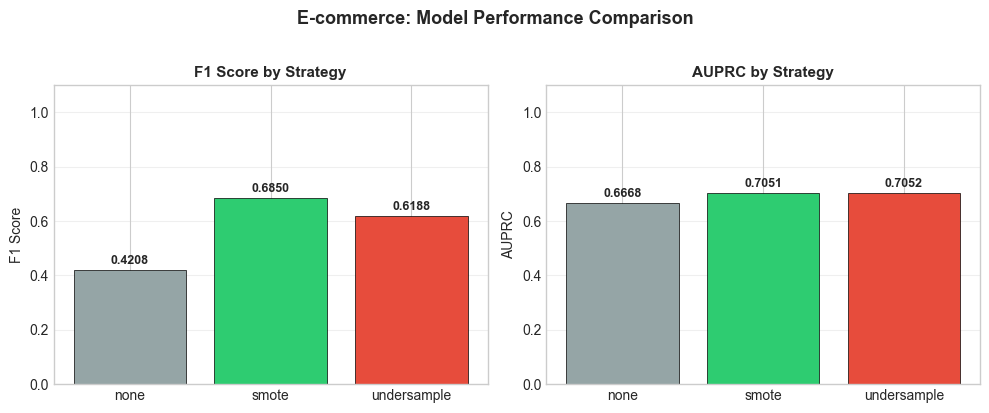

In [13]:
# Strategy comparison bar chart
plot_strategy_comparison(ecomm_results, "E-commerce", "../models/ecomm_comparison")

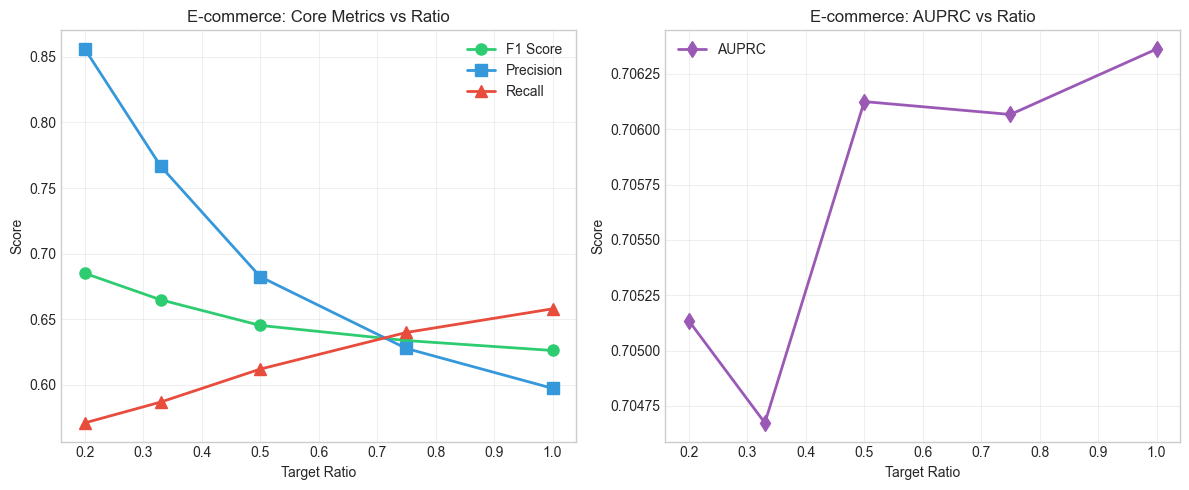

In [14]:
plot_ratio_impact(ecomm_results, "E-commerce", strategy='smote', save_path="../models/ecomm_smote_impact.png")

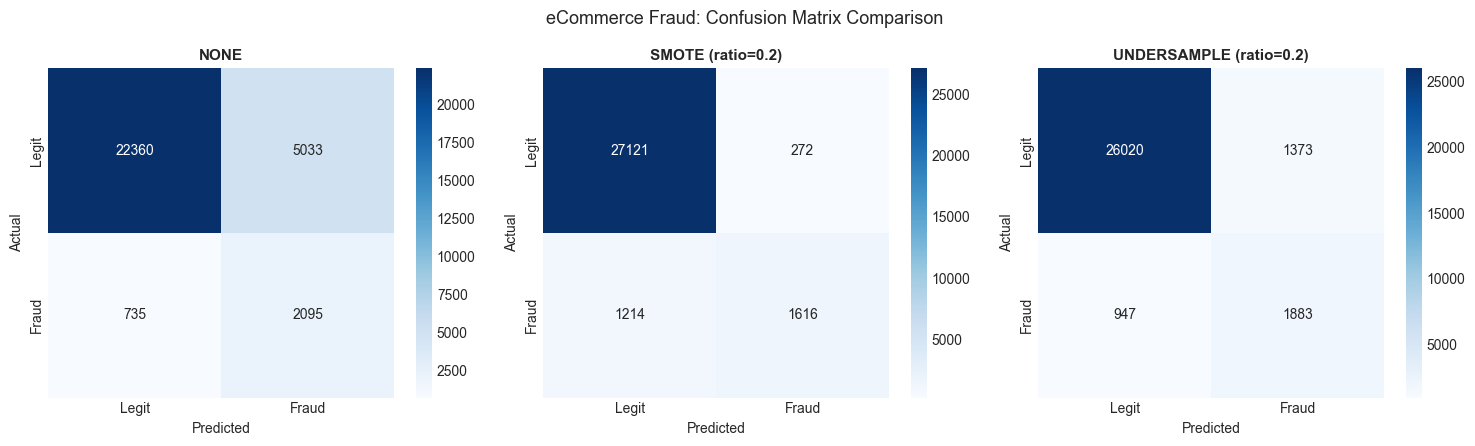

In [15]:
plot_all_confusion_matrices(
    results_list=ecomm_results, 
    dataset_name="eCommerce Fraud"
)

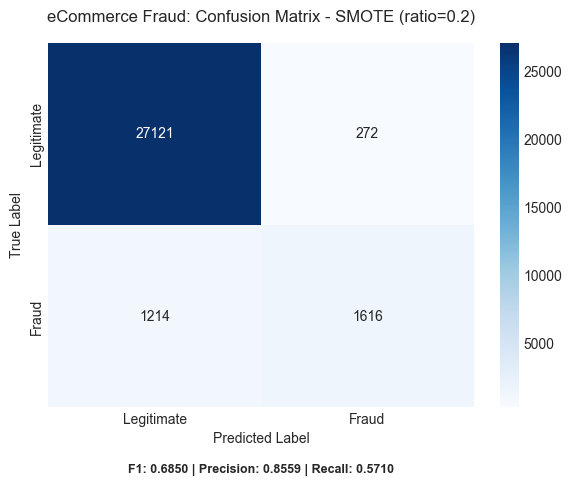

In [16]:
# 1. Find the dictionary with the highest F1-score in your results list
best_model = max(ecomm_results, key=lambda x: x['f1_score'])

# 2. Pass it into your single plotting function
plot_confusion_matrix_heatmap(
    result=best_model, 
    dataset_name="eCommerce Fraud"
)

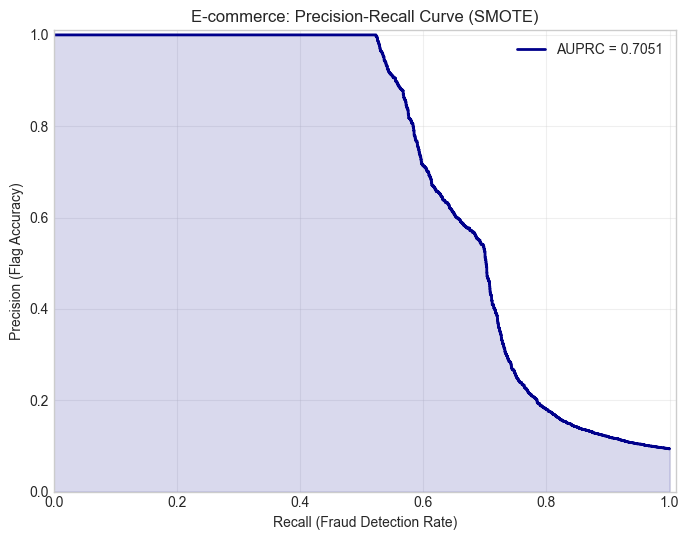

In [17]:
preparer = ModelingPreparer(target_col='class')
_, X_test, _, y_test = preparer.prepare_splits(df_ecomm)
plot_precision_recall_curve(best_model, X_test, y_test, "E-commerce", "../models/ecomm_pr_curve.png")

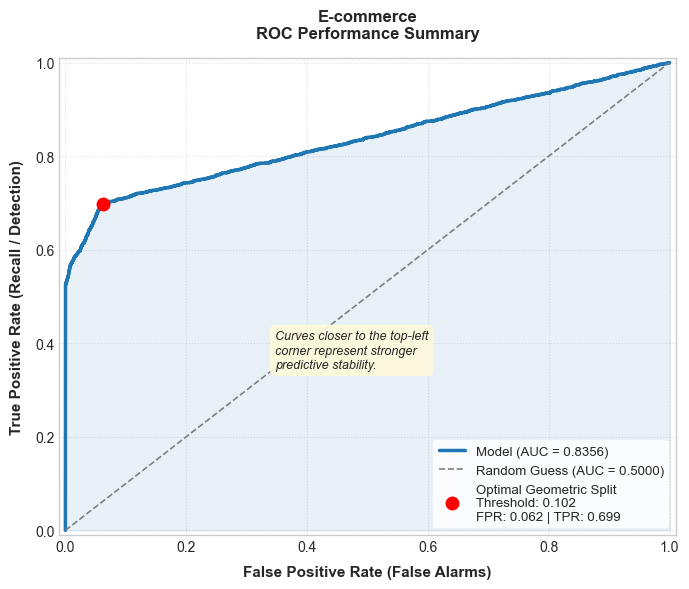

In [18]:
plot_roc_curve(best_model, X_test, y_test, "E-commerce")